# Arabic Sentiment Analysis using MARBERT

## Project Overview

This notebook implements a complete **end-to-end sentiment analysis pipeline** for Arabic company reviews using the **MARBERT** transformer model a state-of-the-art Arabic language model pre-trained on massive Arabic Twitter data.

### Objective
Classify Arabic company reviews into three sentiment classes:
- **Positive** Satisfied customers
- **Negative** Dissatisfied customers
- **Neutral** Mixed or indifferent feedback

### Pipeline Summary
```
Raw Data Cleaning Balancing Tokenization Fine-tuning MARBERT Evaluation Inference
```

### Dataset
Company reviews stored in `CompanyReviews.csv` (loaded from Google Drive).

### Key Technologies
| Component | Tool |
|-----------|------|
| Model | MARBERT (`UBC-NLP/MARBERT`) |
| Framework | HuggingFace Transformers + PyTorch |
| Balancing | RandomOverSampler (imbalanced-learn) |
| Evaluation | scikit-learn metrics |
| Deployment | Streamlit + Cloudflare Tunnel |

## Section 1 Environment Setup

### 1.1 Installing Dependencies

Install all required Python libraries for data preprocessing, model training, evaluation, and visualization.

> **Note:** Run this cell once at the start of each Colab session.

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn imbalanced-learn accelerate


### 1.2 Importing Libraries

Import all necessary libraries: data handling (`pandas`, `numpy`), deep learning (`torch`, `transformers`), machine learning (`sklearn`), oversampling (`imblearn`), and visualization (`matplotlib`, `seaborn`).

In [2]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from imblearn.over_sampling import RandomOverSampler
import warnings
warnings.filterwarnings('ignore')


### 1.3 Reproducibility & Device Configuration

Fix all random seeds to ensure **reproducible results** across runs. Automatically selects **GPU (CUDA)** if available, otherwise falls back to CPU.

> `SEED = 42` is a widely-used convention in ML for reproducibility.

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


## Section 2 Data Loading & Exploration

### 2.1 Mount Google Drive & Load Dataset

Mount Google Drive to access the dataset, then load `CompanyReviews.csv` into a pandas DataFrame.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

file_path = "/content/drive/MyDrive/MARBERT_Sentiment_Project/CompanyReviews.csv"

df = pd.read_csv(file_path)

### 2.2 Exploratory Data Analysis (EDA)

Inspect the dataset structure, data types, and column names to understand the raw data.

In [6]:
df.head()


,Unnamed: 0,review_description,rating,company
0,0,رائع,1,talbat
1,1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          40046 non-null  int64 
 1   review_description  40045 non-null  object
 2   rating              40046 non-null  int64 
 3   company             40046 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.2+ MB


In [8]:
df.columns


Index(['Unnamed: 0', 'review_description', 'rating', 'company'], dtype='object')

### 2.3 Label Distribution Analysis

Analyze class balance across sentiment labels (ratings) and inspect the top companies by review count.

> Understanding class imbalance is critical skewed distributions can bias the model toward the majority class.

In [9]:
df['rating'].value_counts()


,count
rating,
1,23921
-1,14200
0,1925


In [10]:
df['company'].value_counts().head(10)


,count
company,
talbat,32073
swvl,4693
telecom_egypt,2090
venus,281
Raya,268
TMG,250
elsewedy,147
hilton,100
capiter,73


## Section 3 Text Preprocessing

### 3.1 Arabic Text Cleaning & Normalization

Clean and normalize Arabic text through several steps:

| Step | Description |
|------|-------------|
| Remove diacritics | Strip Arabic tashkeel (e.g., ً ٌ ٍ) |
| Unify alef forms | Normalize أ إ آ ا |
| Normalize ya | Normalize ى ي |
| Normalize ta marbuta | Normalize ة ه |
| Remove non-Arabic | Keep only Arabic characters and spaces |
| Collapse whitespace | Remove extra spaces |

> Duplicates are removed after cleaning to avoid data leakage.

In [11]:
def clean_arabic_text(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_review'] = df['review_description'].apply(clean_arabic_text)
df.drop_duplicates(subset='clean_review', inplace=True)


### 3.2 Label Remapping & Class Balancing

Map raw ratings to three sentiment classes and apply **Random Oversampling** to balance the dataset:

| Original Label | Mapped Class | Meaning |
|---------------|--------------|--------|
| `-1` | `0` | Negative |
| `0` | `1` | Neutral |
| `1` | `2` | Positive |

> `RandomOverSampler` duplicates minority-class samples to match the majority class, preventing model bias.

In [12]:
TEXT_COLUMN = 'clean_review'
LABEL_COLUMN = 'rating'

def balance_dataset(df, text_col, label_col):
    df = df.copy()
    df[label_col] = df[label_col].map({-1: 0, 0: 1, 1: 2})
    df = df.dropna(subset=[text_col, label_col])

    ros = RandomOverSampler(random_state=SEED)
    X_res, y_res = ros.fit_resample(df[[text_col]], df[label_col])

    return pd.DataFrame({
        text_col: X_res[text_col],
        label_col: y_res
    })

df_balanced = balance_dataset(df, TEXT_COLUMN, LABEL_COLUMN)


## Section 4 Tokenization

### 4.1 Load MARBERT Tokenizer

Load the pre-trained **MARBERT tokenizer** from HuggingFace. MARBERT uses a WordPiece tokenizer specifically trained on Arabic text.

In [13]:
MODEL_NAME = 'UBC-NLP/MARBERT'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### 4.2 Tokenize the Dataset

Tokenize all reviews with **padding** and **truncation** to a fixed max length of 128 tokens.

> `max_length=128` balances context coverage and memory efficiency for Arabic short reviews.

In [14]:
encoded = tokenizer(
    list(df_balanced[TEXT_COLUMN]),
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

X_ids = encoded['input_ids']
X_mask = encoded['attention_mask']
y = torch.tensor(df_balanced[LABEL_COLUMN].values)


## Section 5 Dataset Splitting

Split the tokenized dataset into **80% training** and **20% testing** using stratified sampling to preserve class distribution in both splits.

In [15]:
X_train_ids, X_test_ids, X_train_mask, X_test_mask, y_train, y_test = train_test_split(
    X_ids, X_mask, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)


## Section 6 Custom PyTorch Dataset

Define a custom `Dataset` class (`ArabicSentimentDataset`) to wrap tokenized inputs and labels into a PyTorch-compatible format required by the HuggingFace `Trainer`.

In [16]:
class ArabicSentimentDataset(torch.utils.data.Dataset):
    def __init__(self, ids, mask, labels):
        self.ids = ids
        self.mask = mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.ids[idx],
            'attention_mask': self.mask[idx],
            'labels': self.labels[idx]
        }

train_dataset = ArabicSentimentDataset(X_train_ids, X_train_mask, y_train)
test_dataset  = ArabicSentimentDataset(X_test_ids, X_test_mask, y_test)


## Section 7 Model Initialization

Load the pre-trained **MARBERT** model and adapt it for **3-class sequence classification** (Negative / Neutral / Positive).

> `ignore_mismatched_sizes=True` is required because we're replacing MARBERT's original classification head with a new 3-class head.

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
).to(device)


pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

## Section 8 Evaluation Metrics

Define custom evaluation metrics for the `Trainer`:
- **Accuracy** Overall correct predictions
- **Weighted F1** F1 score accounting for class imbalance
- **Weighted Precision** Precision per class, weighted by support
- **Weighted Recall** Recall per class, weighted by support

> Weighted averaging is preferred here because class frequencies differ after oversampling.

In [18]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )

    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_weighted': f1,
        'precision_weighted': precision,
        'recall_weighted': recall
    }


## Section 9 Model Training & Loading

### 9.1 Load Pre-trained Fine-tuned Model

The model has already been fine-tuned and saved. Load it directly from Google Drive to skip re-training.

> The training code is preserved below (commented out) for reference and reproducibility.

In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

""" training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(2)]
)

trainer.train() """


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

' training_args = TrainingArguments(\n    output_dir=\'./results\',\n    num_train_epochs=5,\n    per_device_train_batch_size=16,\n    per_device_eval_batch_size=32,\n    eval_strategy="epoch",\n    save_strategy="epoch",\n    load_best_model_at_end=True,\n    metric_for_best_model="f1_weighted",\n    report_to="none",\n    seed=SEED,\n    fp16=torch.cuda.is_available()\n)\n\ntrainer = Trainer(\n    model=model,\n    args=training_args,\n    train_dataset=train_dataset,\n    eval_dataset=test_dataset,\n    compute_metrics=compute_metrics,\n    callbacks=[EarlyStoppingCallback(2)]\n)\n\ntrainer.train() '

### 9.2 Configure Evaluation Arguments

Set up `TrainingArguments` for inference/evaluation only (no training needed).

In [20]:
from transformers import TrainingArguments
import torch

eval_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=32,
    report_to="none",
    fp16=torch.cuda.is_available()
)

### 9.3 Initialize Trainer for Evaluation

Create a `Trainer` instance using the loaded model and evaluation arguments.

In [21]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=test_dataset
)
print(model)
print(eval_args)
print(test_dataset)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(100000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

## Section 10 Model Evaluation

### 10.1 Confusion Matrix

Generate predictions on the test set and visualize the **confusion matrix** to understand per-class performance.

> The confusion matrix reveals which sentiment classes the model confuses most typically Neutral is the hardest to distinguish.

In [22]:
from transformers import TrainingArguments

eval_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=32,
    report_to="none"
)



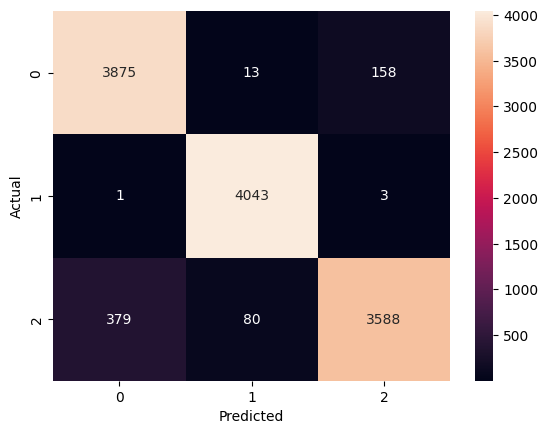

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

from accelerate.state import AcceleratorState
from transformers import TrainingArguments, Trainer

# 1) Reset accelerate global state (fix broken AcceleratorState)
AcceleratorState._reset_state()

# 2) Recreate TrainingArguments (use a fresh object)
eval_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=32,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# 3) Recreate Trainer (IMPORTANT: new Trainer after reset)
trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=test_dataset
)

# 4) Predict
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = preds.label_ids

# 5) Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 10.2 Quantitative Metrics

Compute and print Accuracy, Macro Precision, Macro Recall, and Macro F1-score on the test set.

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")


Accuracy: 0.9478
Macro Precision: 0.9484
Macro Recall: 0.9478
Macro F1-score: 0.9474


### 10.3 Full Classification Report

Display a detailed per-class classification report including precision, recall, F1, and support for each sentiment class.

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))


              precision    recall  f1-score   support

    Negative       0.91      0.96      0.93      4046
     Neutral       0.98      1.00      0.99      4047
    Positive       0.96      0.89      0.92      4047

    accuracy                           0.95     12140
   macro avg       0.95      0.95      0.95     12140
weighted avg       0.95      0.95      0.95     12140



### 10.4 Misclassified Samples Analysis

Inspect the first few misclassified samples to understand model failure modes.

In [26]:
import numpy as np

misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Total Misclassified Samples: {len(misclassified_indices)}")

for i in misclassified_indices[:5]:
    print("True Label:", y_true[i])
    print("Predicted Label:", y_pred[i])


Total Misclassified Samples: 634
True Label: 2
Predicted Label: 0
True Label: 0
Predicted Label: 2
True Label: 2
Predicted Label: 0
True Label: 2
Predicted Label: 0
True Label: 0
Predicted Label: 2


## Section 11 Inference on New Text

### 11.1 Sentiment Prediction Function

Define a helper function `predict_sentiment()` that takes raw Arabic text, cleans it, tokenizes it, and returns the predicted class index (0, 1, or 2).

In [27]:
def predict_sentiment(text):
    text = clean_arabic_text(text)
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=-1).item()

    return pred


### 11.2 Label Mapping

Map numeric predictions to human-readable sentiment labels.

In [28]:
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

def predict_sentiment_label(text):
    pred = predict_sentiment(text)
    return label_map[pred]


### 11.3 Test the Model on a New Example

Run a quick inference test using a sample Arabic review.

In [29]:
predict_sentiment_label("الخدمة ممتازة جدًا")


'Positive'

## Section 12 Data Visualization

### 12.1 Label Distribution: Before vs After Balancing

Compare class distribution before and after applying `RandomOverSampler` to visualize the effect of balancing.

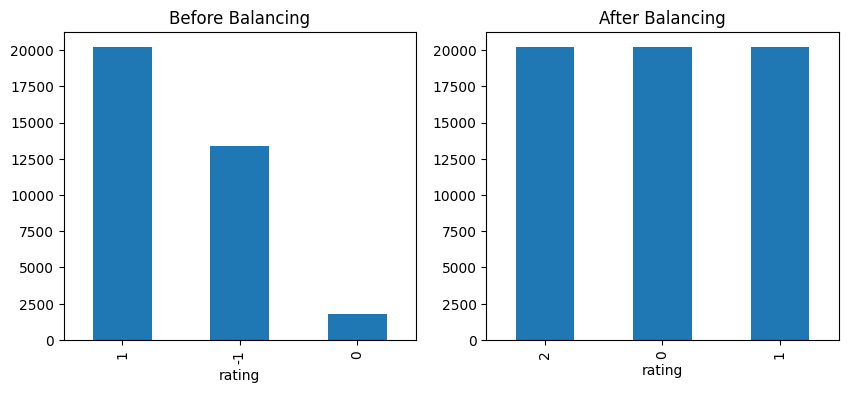

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

df[LABEL_COLUMN].value_counts().plot(kind='bar', ax=ax[0], title="Before Balancing")
df_balanced[LABEL_COLUMN].value_counts().plot(kind='bar', ax=ax[1], title="After Balancing")

plt.show()


## Section 13 Saving the Model

### 13.1 Save Fine-tuned Model to Google Drive

Persist the fine-tuned model and tokenizer to Google Drive for future use without re-training.

> Both `save_model()` and `save_pretrained()` are needed the first saves model weights, the second saves tokenizer vocabulary and config.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model/tokenizer_config.json',
 '/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model/tokenizer.json')

In [32]:
!ls /content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model


config.json	   tokenizer_config.json  training_args.bin
model.safetensors  tokenizer.json


In [33]:
model.save_pretrained("/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model")
tokenizer.save_pretrained("/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model/tokenizer_config.json',
 '/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model/tokenizer.json')

## Section 14 Streamlit Dashboard Deployment

Deploy an interactive Arabic sentiment analysis dashboard using **Streamlit** inside Google Colab, exposed via **Cloudflare Tunnel**.

### Deployment Architecture
```
Colab (port 8501) Cloudflare Tunnel Public URL (trycloudflare.com)
```

### 14.1 Install Streamlit

In [34]:
!python3 -m pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 21.7 MB/s eta 0:00:00


### 14.2 Write the Streamlit App

Write the full Streamlit application to `streamlit_app.py`. The app includes:
- Home page with store selector
- Analysis dashboard with KPI cards, gauge, donut chart, and bar chart
- Stores directory page
- About page
- Arabic/English bilingual support

In [35]:
%%writefile streamlit_app.py

# ─────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────
import base64, re, math
from pathlib import Path
from typing import Optional
import pandas as pd
import streamlit as st
import streamlit.components.v1 as components

# ─────────────────────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────────────────────
st.set_page_config(
    page_title="تحليل تقييمات المتاجر",
    page_icon="⭐", layout="wide",
    initial_sidebar_state="collapsed",
)

# ─────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────
DATA_PATH  = "/content/drive/MyDrive/MARBERT_Sentiment_Project/CompanyReviews.csv"
IMAGE_PATH = "/content/drive/MyDrive/MARBERT_Sentiment_Project/store1.jpg"

STORE_COL  = ["store","store_name","shop","merchant","company","brand"]
TEXT_COL   = ["review","reviews","comment","comments","text","content",
              "review_text","customer_review","customer_review_description","description","body","feedback"]
SENTI_COL  = ["sentiment","label","class","polarity","prediction",
              "predicted_sentiment","sentiment_label","review_sentiment"]
RATING_COL = ["rating","rate","stars","score","review_rating"]

# ─────────────────────────────────────────────────────────
# SESSION STATE
# ─────────────────────────────────────────────────────────
for k,v in {"lang":"ar","selected_store":None,"analysis_started":False,"page":"home"}.items():
    if k not in st.session_state: st.session_state[k] = v

# ─────────────────────────────────────────────────────────
# TRANSLATIONS
# ─────────────────────────────────────────────────────────
UI = {
"ar":{
    "nav_home":"الرئيسية","nav_about":"عن المشروع","nav_stores":"المتاجر",
    "lang_ar":"العربية","lang_en":"English",
    "hero_title":"تحليل تقييمات المتاجر",
    "hero_desc":"منصة ذكية لتحليل آراء العملاء وتصنيف المراجعات\nوفهم تجربة العملاء باحترافية عالية",
    "choose_store":"اختر المتجر","placeholder":"ابحث أو اختر متجراً ...",
    "go_btn":"عرض لوحة التحليل","choose_first":"الرجاء اختيار متجر أولاً.",
    "image_missing":"الصورة غير موجودة.",
    "about_title":"عن المشروع",
    "about_text":"هذا المشروع يحلّل مراجعات المتاجر الإلكترونية ويصنّفها إلى إيجابي وسلبي ومحايد مع لوحة تحكم مرئية احترافية.",
    "stores_title":"المتاجر","reviews":"مراجعة",
    "dashboard_title":"لوحة التحليل","dashboard_text":"نتائج تحليل المراجعات للمتجر المحدد",
    "total_reviews":"إجمالي المراجعات","positive":"إيجابي","negative":"سلبي","neutral":"محايد",
    "pie_title":"توزيع المشاعر","bar_title":"المراجعات حسب التصنيف",
    "summary_title":"الملخص التحليلي",
    "no_sentiment_data":"لم يُعثر على عمود تصنيف أو تقييم.",
    "selected_store_label":"المتجر","source_title":"مصدر التحليل",
    "using_sentiment_col":"عمود المشاعر","using_rating_col":"عمود التقييم","using_none":"لا يوجد عمود واضح",
    "stores_page_desc":"قائمة المتاجر مرتبة حسب عدد المراجعات.",
    "about_page_desc":"منصة تفاعلية لتحليل مراجعات المتاجر الإلكترونية.",
    "back_home":"العودة للرئيسية","satisfaction_index":"مؤشر الرضا",
    "distribution_title":"التوزيع التفصيلي",
    "strong_positive":"الانطباع العام إيجابي جداً",
    "mixed_feedback":"الآراء متباينة وتحتاج مراجعة",
    "needs_attention":"توجد مؤشرات تحتاج اهتماماً",
    "health_gauge_title":"صحة المتجر",
    "excellent_level":"ممتاز","good_level":"جيد","fair_level":"متوسط","weak_level":"ضعيف",
    "valid_reviews":"صالحة للتحليل",
},
"en":{
    "nav_home":"Home","nav_about":"About","nav_stores":"Stores",
    "lang_ar":"العربية","lang_en":"English",
    "hero_title":"Store Review Intelligence",
    "hero_desc":"Smart platform to analyze customer reviews\nand understand store performance professionally",
    "choose_store":"Choose Store","placeholder":"Search or select a store ...",
    "go_btn":"View Analysis Dashboard","choose_first":"Please select a store first.",
    "image_missing":"Image not found.",
    "about_title":"About",
    "about_text":"This platform analyzes e-commerce reviews and classifies them with a professional visual dashboard.",
    "stores_title":"Stores","reviews":"reviews",
    "dashboard_title":"Analysis Dashboard","dashboard_text":"Review analysis results for the selected store",
    "total_reviews":"Total Reviews","positive":"Positive","negative":"Negative","neutral":"Neutral",
    "pie_title":"Sentiment Distribution","bar_title":"Reviews by Sentiment",
    "summary_title":"Summary","no_sentiment_data":"No clear sentiment or rating column found.",
    "selected_store_label":"Store","source_title":"Analysis Source",
    "using_sentiment_col":"Sentiment column","using_rating_col":"Rating column","using_none":"No clear column",
    "stores_page_desc":"Stores sorted by review count.",
    "about_page_desc":"Interactive platform for analyzing e-commerce store reviews.",
    "back_home":"Back to Home","satisfaction_index":"Satisfaction Index",
    "distribution_title":"Detailed Distribution",
    "strong_positive":"Overall impression is strongly positive",
    "mixed_feedback":"Mixed feedback — needs closer review",
    "needs_attention":"Signs of issues that need attention",
    "health_gauge_title":"Store Health",
    "excellent_level":"Excellent","good_level":"Good","fair_level":"Fair","weak_level":"Weak",
    "valid_reviews":"Valid Reviews",
},
}
def tr(k): return UI[st.session_state.lang].get(k,k)

# ─────────────────────────────────────────────────────────
# DATA UTILITIES
# ─────────────────────────────────────────────────────────
@st.cache_data(show_spinner=False)
def load_csv(path):
    p = Path(path)
    if not p.exists(): raise FileNotFoundError(path)
    df = pd.read_csv(p)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def pick_col(df, candidates):
    lc = {str(c).strip().lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lc: return lc[c.lower()]
    return None

def clean_text(v):
    v = str(v)
    v = re.sub(r"http\S+|www\.\S+"," ",v)
    v = re.sub(r"[\r\n\t]+"," ",v)
    v = re.sub(r"[^\w\s\u0600-\u06FF]"," ",v)
    return re.sub(r"\s+"," ",v).strip()

@st.cache_data(show_spinner=False)
def load_stores(path):
    df = load_csv(path)
    sc = pick_col(df, STORE_COL)
    if sc is None: raise ValueError("Store column not found")
    df = df.dropna(subset=[sc]).copy()
    df[sc] = df[sc].astype(str).map(clean_text)
    df = df[df[sc].str.len()>0].copy()
    summary = (df.groupby(sc).size().reset_index(name="n")
                 .sort_values(["n",sc],ascending=[False,True])
                 .reset_index(drop=True))
    return df, summary, sc, pick_col(df,TEXT_COL), pick_col(df,SENTI_COL), pick_col(df,RATING_COL)

@st.cache_data(show_spinner=False)
def img_b64(path):
    p = Path(path)
    return base64.b64encode(p.read_bytes()).decode() if p.exists() else ""

# ─────────────────────────────────────────────────────────
# SENTIMENT
# ─────────────────────────────────────────────────────────
def norm_senti(v):
    if pd.isna(v): return None
    raw = str(v).strip()
    txt = raw.lower().replace("_"," ").replace("-"," ").strip()
    try:
        n = float(raw)
        if n==1: return "Positive"
        if n==0: return "Neutral"
        if n==-1: return "Negative"
        if n>=4: return "Positive"
        if n<=2: return "Negative"
        if n==3: return "Neutral"
    except: pass
    if txt in {"positive","pos","good","great","excellent","ايجابي","إيجابي","ممتاز","جيد"}: return "Positive"
    if txt in {"negative","neg","bad","poor","سلبي","سيء","سيئ"}:                           return "Negative"
    if txt in {"neutral","neu","mixed","محايد","عادي","متعادل"}:                             return "Neutral"
    return None

def rating_senti(v):
    try:
        n=float(v)
        if n==1: return "Positive"
        if n==0: return "Neutral"
        if n==-1: return "Negative"
        if n>=4: return "Positive"
        if n<=2: return "Negative"
        if n==3: return "Neutral"
    except: pass
    return None

def build_senti(data, sc, rc):
    if sc and sc in data.columns:
        s = data[sc].apply(norm_senti)
        if s.notna().sum()>0: return s, sc, "sentiment"
    if rc and rc in data.columns:
        s = data[rc].apply(rating_senti)
        if s.notna().sum()>0: return s, rc, "rating"
    return pd.Series([None]*len(data),index=data.index), None, None

# ─────────────────────────────────────────────────────────
# ANALYTICS
# ─────────────────────────────────────────────────────────
def sat_index(counts):
    t = int(counts.sum())
    if t==0: return 0.0
    return ((counts.get("Positive",0)*1.0 + counts.get("Neutral",0)*0.5)/t)*100

def h_note(pp,np_):
    if pp>=60: return tr("strong_positive")
    if np_>=40: return tr("needs_attention")
    return tr("mixed_feedback")

def h_level(s):
    if s>=80: return tr("excellent_level")
    if s>=60: return tr("good_level")
    if s>=40: return tr("fair_level")
    return tr("weak_level")

def summary_text(counts):
    t=int(counts.sum())
    if t==0: return ""
    top=counts.idxmax(); pct=int(counts.max())/t*100
    ar={"Positive":f"معظم المراجعات إيجابية — رضا عام لدى العملاء. الفئة الأعلى {pct:.1f}%.",
        "Negative":f"معظم المراجعات سلبية — توجد مشكلات تحتاج معالجة. الفئة الأعلى {pct:.1f}%.",
        "Neutral": f"معظم المراجعات محايدة — انطباع عام متوازن. الفئة الأعلى {pct:.1f}%."}
    en={"Positive":f"Most reviews are positive — strong customer satisfaction. Top: {pct:.1f}%.",
        "Negative":f"Most reviews are negative — issues need attention. Top: {pct:.1f}%.",
        "Neutral": f"Most reviews are neutral — balanced overall impression. Top: {pct:.1f}%."}
    return ar.get(top,"") if st.session_state.lang=="ar" else en.get(top,"")

# ─────────────────────────────────────────────────────────
# CHART COLORS — green / red / amber
# ─────────────────────────────────────────────────────────
C_POS = "#5fa87a"   # soft green    — إيجابي
C_NEG = "#c96b6b"   # soft red      — سلبي
C_NEU = "#c9a84c"   # warm amber    — محايد

# ─────────────────────────────────────────────────────────
# SVG DONUT CHART
# ─────────────────────────────────────────────────────────
def svg_donut(counts, labels):
    pos=int(counts.get("Positive",0))
    neg=int(counts.get("Negative",0))
    neu=int(counts.get("Neutral",0))
    total=pos+neg+neu
    if total==0:
        return "<div style='text-align:center;padding:40px;color:#b5a898;'>لا توجد بيانات</div>"

    cx,cy,ro,ri = 110,110,95,58
    def arc(val,start,color):
        if val==0: return ""
        frac=val/total; deg=frac*360
        if deg>=359.99: deg=359.99
        end=start+deg
        def pt(a,r):
            rad=math.radians(a-90)
            return cx+r*math.cos(rad), cy+r*math.sin(rad)
        x1o,y1o=pt(start,ro); x2o,y2o=pt(end,ro)
        x1i,y1i=pt(start,ri); x2i,y2i=pt(end,ri)
        laf=1 if deg>180 else 0
        return (f'<path d="M{x1o:.1f},{y1o:.1f} A{ro},{ro} 0 {laf},1 {x2o:.1f},{y2o:.1f} '
                f'L{x2i:.1f},{y2i:.1f} A{ri},{ri} 0 {laf},0 {x1i:.1f},{y1i:.1f}Z" '
                f'fill="{color}" stroke="#fff" stroke-width="3"/>')

    a=0; svgp=""
    for v,c in [(pos,C_POS),(neg,C_NEG),(neu,C_NEU)]:
        svgp+=arc(v,a,c); a+=v/total*360

    pct_p=pos/total*100; pct_n=neg/total*100; pct_u=neu/total*100
    top_lbl  = labels[0] if pos>=neg and pos>=neu else (labels[1] if neg>=neu else labels[2])
    top_pct  = max(pct_p,pct_n,pct_u)
    top_col  = C_POS if pos>=neg and pos>=neu else (C_NEG if neg>=neu else C_NEU)

    legend=""
    for lbl,val,pct,col in [(labels[0],pos,pct_p,C_POS),(labels[1],neg,pct_n,C_NEG),(labels[2],neu,pct_u,C_NEU)]:
        legend+=f"""
        <div style="display:flex;align-items:center;gap:10px;margin-bottom:12px;direction:rtl;">
          <span style="width:12px;height:12px;border-radius:4px;background:{col};
                       display:inline-block;flex-shrink:0;"></span>
          <span style="font-size:14px;font-weight:700;color:#2d2416;">{lbl}</span>
          <span style="font-size:13px;color:#8a7968;margin-right:auto;">{pct:.1f}% &nbsp;({val:,})</span>
        </div>"""

    return f"""
    <div style="display:flex;align-items:center;gap:28px;flex-wrap:wrap;
                justify-content:center;padding:12px 0 4px;">
      <div style="position:relative;">
        <svg width="220" height="220" viewBox="0 0 220 220">
          {svgp}
          <circle cx="110" cy="110" r="46" fill="#f8fafc"/>
          <text x="110" y="105" text-anchor="middle" font-size="26" font-weight="900"
                fill="{top_col}" font-family="Cairo,sans-serif">{top_pct:.0f}%</text>
          <text x="110" y="126" text-anchor="middle" font-size="13" fill="#8a7968"
                font-family="Cairo,sans-serif">{top_lbl}</text>
        </svg>
      </div>
      <div style="min-width:170px;">{legend}</div>
    </div>"""

# ─────────────────────────────────────────────────────────
# HTML HORIZONTAL BAR CHART
# ─────────────────────────────────────────────────────────
def html_bars(counts, labels):
    maxv = max(int(counts.max()) if counts.sum()>0 else 1, 1)
    out=""
    for key,lbl,col in zip(["Positive","Negative","Neutral"],labels,[C_POS,C_NEG,C_NEU]):
        val=int(counts.get(key,0))
        pct=val/maxv*100
        bar_bg = col+"22"
        out+=f"""
        <div style="margin-bottom:22px;">
          <div style="display:flex;justify-content:space-between;
                      align-items:center;margin-bottom:8px;direction:rtl;">
            <span style="font-size:14px;font-weight:700;color:#2d2416;">{lbl}</span>
            <span style="font-size:15px;font-weight:900;color:{col};">{val:,}</span>
          </div>
          <div style="background:{bar_bg};border-radius:99px;height:14px;
                      overflow:hidden;position:relative;">
            <div style="width:{pct:.1f}%;height:100%;background:{col};
                        border-radius:99px;transition:width .8s ease;"></div>
          </div>
        </div>"""
    return out

# ─────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────
try:
    df, summary, store_col, text_col, senti_col, rating_col = load_stores(DATA_PATH)
except Exception as e:
    st.error(f"خطأ في البيانات: {e}"); st.stop()

IMAGE_B64 = img_b64(IMAGE_PATH)

# ─────────────────────────────────────────────────────────
# CSS
# ─────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Cairo:wght@400;600;700;800;900&display=swap');

#MainMenu,footer,header,
[data-testid="stToolbar"],
[data-testid="stSidebar"],
[data-testid="stDecoration"]{display:none!important;}

*,html,body,[class*="css"],.stApp,p,span,label,div,button,input{
    font-family:"Cairo",sans-serif!important;
    direction:rtl;
    box-sizing:border-box;
}

.stApp{
    background:linear-gradient(160deg,#fdf8f0 0%,#f5efe2 50%,#eef5ef 100%)!important;
    color:#2d2416!important;
}
/* Remove ALL padding/margin above topbar */
section.main > div.block-container{
    padding-top:0!important;
    padding-left:0!important;
    padding-right:0!important;
    padding-bottom:60px!important;
    max-width:100%!important;
    margin-top:0!important;
}
section[tabindex="0"]{
    padding-top:0!important;
    margin-top:0!important;
}
.main{ padding-top:0!important; }
[data-testid="stAppViewContainer"]>section>div{
    padding-top:0!important;
}
/* Kill the streamlit default top spacing completely */
[data-testid="stAppViewContainer"]{
    padding-top:0!important;
}
div[data-testid="stMainBlockContainer"]{
    padding-top:0!important;
}

/* ══════════════════════════════════
   TOPBAR — same color as background, flush to top
   ══════════════════════════════════ */
div[data-testid="stHorizontalBlock"]:has(.lang-wrap):has(.nav-btn){
    background:transparent!important;
    border-bottom:none!important;
    border-radius:0!important;
    padding:0 48px!important;
    margin:0!important;
    max-width:100vw!important;
    width:100vw!important;
    left:0!important; right:0!important;
    box-shadow:none!important;
    position:sticky!important;
    top:0!important;
    z-index:1000!important;
    min-height:56px!important;
    max-height:56px!important;
    display:flex!important;
    align-items:center!important;
    backdrop-filter:blur(8px)!important;
    -webkit-backdrop-filter:blur(8px)!important;
}
div[data-testid="stHorizontalBlock"]{ align-items:center; }

/* ══ UNIFIED BEIGE BOX STYLE — ALL interactive elements ══ */
button[kind="secondary"],
button[kind="primary"],
button[data-testid="baseButton-secondary"],
button[data-testid="baseButton-primary"],
.stButton button,
.nav-btn button,
.nav-btn .stButton>button,
.nav-btn div[data-testid="stButton"]>button{
    border-radius:10px!important;
    border:1.5px solid #d4c8b8!important;
    background:#fdf6ec!important;
    background-color:#fdf6ec!important;
    color:#4a3f32!important;
    font-weight:700!important;
    box-shadow:none!important;
    transition:all .18s!important;
}
button[kind="secondary"]:hover,
button[kind="primary"]:hover,
button[data-testid="baseButton-secondary"]:hover,
.stButton button:hover,
.nav-btn button:hover,
.nav-btn .stButton>button:hover{
    background:#f0e6d3!important;
    background-color:#f0e6d3!important;
    border-color:#c4b8a4!important;
    color:#2d2416!important;
}

/* CTA button specific sizing */
.go-btn button,
.go-btn .stButton>button,
.go-btn div[data-testid="stButton"]>button,
.page-action-btn button,
.page-action-btn .stButton>button,
.page-action-btn div[data-testid="stButton"]>button{
    width:100%!important;
    min-height:46px!important;
    font-size:15px!important;
    font-weight:800!important;
}
.go-btn button:hover,
.go-btn .stButton>button:hover{
    transform:translateY(-1px)!important;
}

/* All dropdowns / selects */
.lang-wrap div[data-baseweb="select"]>div,
.store-wrap div[data-baseweb="select"]>div,
div[data-baseweb="select"]>div,
div[role="combobox"]{
    background:#fdf6ec!important;
    background-color:#fdf6ec!important;
    border:1.5px solid #d4c8b8!important;
    border-radius:10px!important;
    color:#2d2416!important;
    box-shadow:none!important;
    min-height:40px!important;
}
.store-wrap div[data-baseweb="select"]>div{
    min-height:48px!important;
}
div[data-baseweb="select"]>div:focus-within,
div[role="combobox"]:focus-within{
    border-color:#a89070!important;
    box-shadow:0 0 0 3px rgba(180,150,100,0.12)!important;
}
div[role="listbox"],ul[role="listbox"]{
    background:#fdf8f0!important;
    border:1px solid #d4c8b8!important;
    border-radius:12px!important;
    box-shadow:0 8px 24px rgba(0,0,0,0.10)!important;
}
div[role="option"],li[role="option"]{
    background:#fdf8f0!important;color:#2d2416!important;font-size:14px!important;
}
div[role="option"]:hover{ background:#e5d5bc!important; color:#2d2416!important; }
[data-baseweb="select"] *{ color:#2d2416!important; font-weight:600!important; }
[data-baseweb="select"] svg{ fill:#8a7968!important; }
input,textarea{
    background:transparent!important;
    color:#2d2416!important;
    -webkit-text-fill-color:#2d2416!important;
}

/* ══════════════════════════════════
   HERO CONTENT STYLES
   ══════════════════════════════════ */
.hero-title{
    font-size:38px;font-weight:900;color:#6B4423;
    line-height:1.15;margin:0 0 12px;letter-spacing:-0.6px;
    text-align:center;
}
.hero-desc{
    font-size:14px;line-height:1.9;color:#6B4423;
    white-space:pre-line;margin:0 0 24px;
    text-align:center;
}
.hero-store-label{
    font-size:13px;font-weight:800;color:#6B4423;
    margin-bottom:8px;letter-spacing:0.2px;
    text-align:right;
}
.hero-image{
    width:100%;max-width:420px;
    mix-blend-mode:multiply;
    filter:saturate(0.92) brightness(1.02);
    mask-image:radial-gradient(ellipse 90% 88% at 50% 48%, black 52%, transparent 100%);
    -webkit-mask-image:radial-gradient(ellipse 90% 88% at 50% 48%, black 52%, transparent 100%);
}
.hero-img-wrap{
    display:flex;align-items:center;justify-content:center;
    height:100%;min-height:260px;
}
.hero-content{
    display:flex;flex-direction:column;
    justify-content:center;height:100%;
}

/* ══════════════════════════════════
   DASHBOARD WRAPPER
   ══════════════════════════════════ */
.dash-wrapper{
    padding:40px 80px 0;
    background:transparent;
}
.section-title{
    font-size:28px;font-weight:900;text-align:center;color:#6B4423;margin:0 0 6px;
}
.section-sub{
    font-size:14px;color:#6B4423;text-align:center;
    margin:0 auto 32px;max-width:560px;line-height:1.85;
}

/* ══════════════════════════════════
   KPI CARDS
   ══════════════════════════════════ */
.kpi-card{
    background:#fdf6ec;
    border:1.5px solid #d4c8b8;
    border-radius:16px;
    padding:20px 14px 16px;
    text-align:center;
    box-shadow:0 1px 4px rgba(150,120,80,0.06);
    transition:box-shadow .2s,transform .2s;
    height:100%;
    min-height:100px;
    display:flex;flex-direction:column;
    justify-content:center;align-items:center;
}
.kpi-card:hover{
    box-shadow:0 6px 20px rgba(150,120,80,0.12);
    transform:translateY(-2px);
}
.kpi-label{
    font-size:11px;font-weight:800;color:#b5a898;
    text-transform:uppercase;letter-spacing:1px;margin-bottom:8px;
}
.kpi-value{ font-size:26px;font-weight:900;color:#2d1f0e;line-height:1; }
.kpi-sub{   font-size:11px;color:#b5a898;margin-top:6px; }
.kpi-card.pos .kpi-value{ color:#5fa87a; }
.kpi-card.neg .kpi-value{ color:#c96b6b; }
.kpi-card.neu .kpi-value{ color:#c9a84c; }

/* ══════════════════════════════════
   CONTENT CARDS
   ══════════════════════════════════ */
.content-card{
    background:#fdf6ec;
    border:1.5px solid #d4c8b8;
    border-radius:16px;
    padding:22px 20px;
    box-shadow:0 1px 4px rgba(150,120,80,0.06);
    margin-top:0;
}
.card-title{
    font-size:11px;font-weight:800;color:#b5a898;
    text-transform:uppercase;letter-spacing:1px;margin-bottom:16px;
}
.card-big-num{ font-size:36px;font-weight:900;color:#1a1208;margin-bottom:4px; }
.card-note{    font-size:13px;color:#6b5e4e;line-height:1.8; }

/* ══════════════════════════════════
   GAUGE
   ══════════════════════════════════ */
.gauge-wrap{ display:flex;justify-content:center;padding:8px 0 14px; }
.gauge-ring{
    width:130px;height:130px;border-radius:50%;
    display:flex;align-items:center;justify-content:center;
    box-shadow:0 4px 16px rgba(90,171,130,0.15);
}
.gauge-inner{
    width:88px;height:88px;border-radius:50%;
    background:#faf7f2;
    display:flex;flex-direction:column;align-items:center;justify-content:center;
    box-shadow:inset 0 2px 6px rgba(0,0,0,0.06);
}
.gauge-num{ font-size:22px;font-weight:900;color:#1a1208;line-height:1.1; }
.gauge-lev{ font-size:11px;font-weight:700;color:#8a7968;margin-top:3px; }

/* ══════════════════════════════════
   PROGRESS BARS
   ══════════════════════════════════ */
.prog-row{ margin-bottom:16px; }
.prog-row:last-child{ margin-bottom:0; }
.prog-head{
    display:flex;justify-content:space-between;
    font-size:13px;font-weight:700;color:#4a3f32;margin-bottom:8px;
}
.prog-track{
    width:100%;height:10px;
    background:#f0ece5;border-radius:99px;overflow:hidden;
}
.prog-fill{ height:100%;border-radius:99px;transition:width .7s ease; }
.prog-pos{ background:#5fa87a; }
.prog-neg{ background:#c96b6b; }
.prog-neu{ background:#c9a84c; }

/* ══════════════════════════════════
   STORE GRID CARDS
   ══════════════════════════════════ */
.store-card{
    background:#fdf6ec;border:1px solid #ddd5c8;
    border-radius:16px;padding:20px 16px;text-align:center;
    margin-top:12px;transition:all .2s;
    box-shadow:0 1px 4px rgba(0,0,0,0.04);
}
.store-card:hover{ box-shadow:0 6px 20px rgba(90,171,130,0.14);transform:translateY(-3px); }
.store-name{ font-size:14px;font-weight:800;color:#6B4423;margin-bottom:6px; }
.store-meta{ font-size:12px;color:#6B4423; }

/* Empty state */
.empty-state{
    background:#fdf8f0;border:2px dashed #ddd5c8;
    border-radius:20px;padding:72px 32px;text-align:center;margin-top:24px;
}
.empty-icon{ font-size:52px;margin-bottom:18px; }
.empty-text{ font-size:15px;color:#b5a898;line-height:1.85; }

/* Divider */
.divider{ height:1px;background:linear-gradient(90deg,transparent,#ddd5c8,transparent); }

[data-testid="stHeader"]{ height:0;min-height:0; }

@media(max-width:900px){
    .hero-outer{ padding:40px 24px 36px; }
    .dash-wrapper{ padding:32px 20px 0; }
    .hero-title{ font-size:30px; }
    .kpi-value{ font-size:22px; }
}
</style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────
# TOPBAR  (full-width sticky)
# ─────────────────────────────────────────────────────────
with st.container():
    tl, tc, tr_ = st.columns([1.2, 6, 1.2], vertical_alignment="center")

    with tl:
        st.markdown('<div class="lang-wrap">', unsafe_allow_html=True)
        lmap = {"العربية":"ar","English":"en"}
        sl   = st.selectbox("", list(lmap.keys()),
                            index=0 if st.session_state.lang=="ar" else 1,
                            label_visibility="collapsed", key="lang_sw")
        if lmap[sl] != st.session_state.lang:
            st.session_state.lang = lmap[sl]; st.rerun()
        st.markdown("</div>", unsafe_allow_html=True)

    with tc:
        n1,n2,n3 = st.columns(3, gap="small")
        for col,key,tgt in [(n1,"nav_home","home"),(n2,"nav_about","about"),(n3,"nav_stores","stores")]:
            with col:
                st.markdown('<div class="nav-btn">', unsafe_allow_html=True)
                if st.button(tr(key), key=f"nav_{tgt}", use_container_width=True):
                    st.session_state.page=tgt; st.rerun()
                st.markdown("</div>", unsafe_allow_html=True)

    with tr_:
        st.empty()

# ─────────────────────────────────────────────────────────
# PAGE: HOME
# ─────────────────────────────────────────────────────────
if st.session_state.page == "home":

    disp = summary[store_col].astype(str)+" — "+summary["n"].astype(str)+" "+tr("reviews")
    d2s  = dict(zip(disp, summary[store_col]))
    ph   = tr("placeholder")

    # ── Hero ──
    hl, hr = st.columns([1.05, 0.95], gap="large")

    with hl:
        st.markdown('<div class="hero-content">', unsafe_allow_html=True)
        st.markdown(f'<div class="hero-title">{tr("hero_title")}</div>', unsafe_allow_html=True)
        st.markdown(f'<div class="hero-desc">{tr("hero_desc")}</div>',   unsafe_allow_html=True)
        st.markdown(f'<div class="hero-store-label">{tr("choose_store")}</div>', unsafe_allow_html=True)
        st.markdown('<div class="store-wrap">', unsafe_allow_html=True)
        sel = st.selectbox("", [ph]+list(disp), label_visibility="collapsed", key="store_sel")
        st.markdown("</div>", unsafe_allow_html=True)
        st.markdown("<div style='height:12px'></div>", unsafe_allow_html=True)
        st.markdown('<div class="go-btn">', unsafe_allow_html=True)
        clicked = st.button(tr("go_btn"), key="go_btn", use_container_width=True)
        if clicked:
            if sel == ph:
                st.warning(tr("choose_first"))
                st.session_state.analysis_started = False
            else:
                st.session_state.selected_store   = d2s[sel]
                st.session_state.analysis_started = True
        st.markdown("</div></div>", unsafe_allow_html=True)

    with hr:
        if IMAGE_B64:
            st.markdown(
                f'<div class="hero-img-wrap">'
                f'<img class="hero-image" src="data:image/jpeg;base64,{IMAGE_B64}"></div>',
                unsafe_allow_html=True)

    # ── Auto-scroll to dashboard ──
    if st.session_state.analysis_started:
        components.html("""<script>
        (function scroll(){
            var el=window.parent.document.getElementById('dash-anchor');
            if(el){ el.scrollIntoView({behavior:'smooth',block:'start'}); }
            else   { setTimeout(scroll,200); }
        })();
        setTimeout(function(){
            var el=window.parent.document.getElementById('dash-anchor');
            if(el) el.scrollIntoView({behavior:'smooth',block:'start'});
        },700);
        </script>""", height=0)

    # ── Dashboard ──
    st.markdown('<div id="dash-anchor" style="scroll-margin-top:72px;"></div>', unsafe_allow_html=True)
    st.markdown('<div class="divider"></div>', unsafe_allow_html=True)

    st.markdown('<div class="dash-wrapper">', unsafe_allow_html=True)
    st.markdown(f'<div class="section-title">{tr("dashboard_title")}</div>', unsafe_allow_html=True)
    st.markdown(f'<div class="section-sub">{tr("dashboard_text")}</div>',   unsafe_allow_html=True)

    if st.session_state.analysis_started and st.session_state.selected_store:

        sdf = df[df[store_col].astype(str)==str(st.session_state.selected_store)].copy()
        ss, ucol, utype = build_senti(sdf, senti_col, rating_col)
        sdf["__s__"] = ss

        valid  = sdf["__s__"].dropna()
        counts = valid.value_counts().reindex(["Positive","Negative","Neutral"],fill_value=0)
        total  = len(sdf); vt=int(counts.sum())
        pos_n=int(counts["Positive"]); neg_n=int(counts["Negative"]); neu_n=int(counts["Neutral"])
        pos_p = pos_n/vt*100 if vt else 0
        neg_p = neg_n/vt*100 if vt else 0
        neu_p = neu_n/vt*100 if vt else 0
        sat   = sat_index(counts)
        hnote = h_note(pos_p, neg_p)
        hlev  = h_level(sat)
        lpos,lneg,lneu = tr("positive"),tr("negative"),tr("neutral")

        src = (f"{tr('using_sentiment_col')}: {ucol}" if utype=="sentiment"
               else f"{tr('using_rating_col')}: {ucol}" if utype=="rating"
               else tr("using_none"))

        # ── Shared vars ──
        sc2          = max(0, min(100, sat))
        g_col        = "#5fa87a" if sc2>=60 else ("#c9a84c" if sc2>=40 else "#c96b6b")
        g_bg         = "#e8e0d4"
        chart_labels = [lpos, lneg, lneu]

        # ── Row 1: 5 equal KPI cards (store same size as total) ──
        k1,k2,k3,k4,k5 = st.columns(5, gap="small")
        store_name    = str(st.session_state.selected_store)
        store_display = store_name if len(store_name)<=10 else store_name[:10]+"…"
        kpi_rows = [
            ("#6B4423", tr("selected_store_label"), store_display, "\u00a0"),
            ("#6B4423", tr("total_reviews"),        f"{total:,}",  f"{tr('valid_reviews')}: {vt:,}"),
            ("#5fa87a", tr("positive"),             f"{pos_n:,}",  f"{pos_p:.1f}%"),
            ("#c96b6b", tr("negative"),             f"{neg_n:,}",  f"{neg_p:.1f}%"),
            ("#c9a84c", tr("neutral"),              f"{neu_n:,}",  f"{neu_p:.1f}%"),
        ]
        for col,(vc,lbl,val,sub) in zip([k1,k2,k3,k4,k5], kpi_rows):
            with col:
                st.markdown(f"""
                <div class="kpi-card" style="min-height:108px;">
                  <div class="kpi-label">{lbl}</div>
                  <div class="kpi-value" style="color:{vc};font-size:24px;">{val}</div>
                  <div class="kpi-sub">{sub}</div>
                </div>""", unsafe_allow_html=True)

        st.markdown("<div style='height:14px'></div>", unsafe_allow_html=True)

        # SVG semicircle gauge
        def svg_semicircle(score, color, bg_color, level, note):
            pct   = min(score, 99.9) / 100
            angle = pct * 180
            rad   = math.radians(180 - angle)
            cx, cy, r = 110, 105, 80
            ex  = cx + r * math.cos(rad)
            ey  = cy - r * math.sin(rad)
            laf = 1 if angle > 180 else 0
            return f"""
            <div style="text-align:center;padding:12px 0 4px;">
              <svg width="200" height="120" viewBox="0 0 220 120">
                <path d="M 30,110 A 80,80 0 0,1 190,110"
                      fill="none" stroke="{bg_color}" stroke-width="20" stroke-linecap="round"/>
                <path d="M 30,110 A 80,80 0 {laf},1 {ex:.2f},{ey:.2f}"
                      fill="none" stroke="{color}" stroke-width="20" stroke-linecap="round"
                      style="filter:drop-shadow(0 0 6px {color}99);"/>
                <text x="110" y="90" text-anchor="middle" font-size="36" font-weight="900"
                      fill="#1a1208" font-family="Cairo,sans-serif">{score:.0f}</text>
                <text x="110" y="112" text-anchor="middle" font-size="13" font-weight="800"
                      fill="{color}" font-family="Cairo,sans-serif">{level}</text>
              </svg>
              <div style="font-size:12px;color:#8a7968;margin-top:6px;">{note}</div>
            </div>"""

        dist_html = f"""
        <div class="prog-row">
          <div class="prog-head"><span>{lpos}</span><span>{pos_p:.1f}% · {pos_n:,}</span></div>
          <div class="prog-track"><div class="prog-fill prog-pos" style="width:{pos_p:.1f}%"></div></div>
        </div>
        <div class="prog-row">
          <div class="prog-head"><span>{lneg}</span><span>{neg_p:.1f}% · {neg_n:,}</span></div>
          <div class="prog-track"><div class="prog-fill prog-neg" style="width:{neg_p:.1f}%"></div></div>
        </div>
        <div class="prog-row">
          <div class="prog-head"><span>{lneu}</span><span>{neu_p:.1f}% · {neu_n:,}</span></div>
          <div class="prog-track"><div class="prog-fill prog-neu" style="width:{neu_p:.1f}%"></div></div>
        </div>"""

        # ── Layout: Summary  (full height) | Gauge + Donut  (stacked) ──
        col_left, col_right = st.columns([1, 1], gap="small")

        with col_left:
            st.markdown(f"""
            <div class="content-card" style="
                min-height:600px;
                display:flex;
                flex-direction:column;
                justify-content:center;
                align-items:center;
                text-align:center;
                box-sizing:border-box;
            ">
              <div class="card-title" style="margin-bottom:14px;">{tr("summary_title")}</div>
              <div style="font-size:54px;font-weight:900;color:{g_col};line-height:1;margin-bottom:6px;">
                {sc2:.1f}%
              </div>
              <div style="font-size:12px;color:#b5a898;margin-bottom:16px;
                          text-transform:uppercase;letter-spacing:0.7px;font-weight:700;">
                {tr("satisfaction_index")}
              </div>
              <div style="font-size:14px;color:#4a3f32;line-height:1.9;
                          max-width:360px;margin-bottom:24px;">
                {summary_text(counts)}
              </div>
              <div style="width:100%;padding-top:18px;border-top:1px solid #ede8e0;">
                <div class="card-title" style="margin-bottom:14px;text-align:center;">
                  {tr("distribution_title")}
                </div>
                {dist_html}
              </div>
              <div style="margin-top:12px;font-size:11px;color:#b5a898;">
                {tr("source_title")}: {src}
              </div>
            </div>""", unsafe_allow_html=True)

        with col_right:
            # Gauge top — fixed height
            st.markdown(f"""
            <div class="content-card" style="text-align:center;min-height:268px;display:flex;flex-direction:column;justify-content:center;">
              <div class="card-title">{tr("health_gauge_title")}</div>
              {svg_semicircle(sc2, g_col, g_bg, hlev, hnote)}
            </div>""", unsafe_allow_html=True)

            st.markdown("<div style='height:14px'></div>", unsafe_allow_html=True)

            # Donut bottom — fixed height
            st.markdown(f"""
            <div class="content-card" style="min-height:298px;display:flex;flex-direction:column;justify-content:center;">
             <div class="card-title" style="text-align:center;">{tr("pie_title")}</div>
              {svg_donut(counts, chart_labels)}
            </div>""", unsafe_allow_html=True)

        st.markdown("<div style='height:40px'></div>", unsafe_allow_html=True)

    else:
        st.markdown(f"""
        <div class="empty-state">
          <div class="empty-icon">📊</div>
          <div class="empty-text">{tr("choose_first")}</div>
        </div>""", unsafe_allow_html=True)
        st.markdown("<div style='height:40px'></div>", unsafe_allow_html=True)

    st.markdown("</div>", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────
# PAGE: ABOUT
# ─────────────────────────────────────────────────────────
elif st.session_state.page == "about":
    st.markdown("<div style='height:48px'></div>", unsafe_allow_html=True)
    st.markdown(f'<div class="section-title">{tr("about_title")}</div>', unsafe_allow_html=True)
    st.markdown(f'<div class="section-sub">{tr("about_page_desc")}</div>', unsafe_allow_html=True)
    c1,c2,c3 = st.columns([1,2.5,1])
    with c2:
        st.markdown(f"""
        <div class="content-card" style="text-align:center;padding:44px 32px;margin-top:0;">
          <div class="card-title" style="margin-bottom:18px;">{tr("about_title")}</div>
          <div class="card-note">{tr("about_text")}</div>
        </div>""", unsafe_allow_html=True)
        st.markdown("<div style='height:20px'></div>", unsafe_allow_html=True)
        st.markdown('<div class="go-btn">', unsafe_allow_html=True)
        if st.button(tr("back_home"), key="back_about", use_container_width=True):
            st.session_state.page="home"; st.rerun()
        st.markdown("</div>", unsafe_allow_html=True)

# ─────────────────────────────────────────────────────────
# PAGE: STORES
# ─────────────────────────────────────────────────────────
elif st.session_state.page == "stores":
    st.markdown("<div style='height:48px'></div>", unsafe_allow_html=True)
    st.markdown(f'<div class="section-title">{tr("stores_title")}</div>', unsafe_allow_html=True)
    st.markdown(f'<div class="section-sub">{tr("stores_page_desc")}</div>', unsafe_allow_html=True)
    st.markdown("<div style='padding:0 80px;'>", unsafe_allow_html=True)
    top = summary.head(12)
    for chunk in [top.iloc[i:i+4] for i in range(0,len(top),4)]:
        cols = st.columns(4, gap="small")
        for idx,(_,row) in enumerate(chunk.iterrows()):
            with cols[idx]:
                st.markdown(f"""
                <div class="store-card">
                  <div class="store-name">{row[store_col]}</div>
                  <div class="store-meta">{int(row['n']):,} {tr("reviews")}</div>
                </div>""", unsafe_allow_html=True)
    st.markdown("</div>", unsafe_allow_html=True)
    st.markdown("<div style='height:28px'></div>", unsafe_allow_html=True)
    c1,c2,c3 = st.columns([1,2,1])
    with c2:
        st.markdown('<div class="go-btn">', unsafe_allow_html=True)
        if st.button(tr("back_home"), key="back_stores", use_container_width=True):
            st.session_state.page="home"; st.rerun()
        st.markdown("</div>", unsafe_allow_html=True)

Writing streamlit_app.py


### 14.3 Install Supporting Libraries

In [36]:
!pip -q install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.2 MB/s eta 0:00:00


### 14.4 Launch the Streamlit Server

In [37]:
!pkill -f streamlit || true
!nohup python3 -m streamlit run streamlit_app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true > streamlit.log 2>&1 &

^C


### 14.5 Install & Launch Cloudflare Tunnel

Install `cloudflared` and create a public tunnel to expose the Streamlit app.

In [38]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.6.0) ...
Setting up cloudflared (2026.6.0) ...
Processing triggers for man-db (2.10.2-1) ...


### 14.6 Mount Drive & Set Model Path for App

In [39]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
MODEL_PATH = "/content/drive/MyDrive/MARBERT_Sentiment_Project/sentiment_model"

### 14.7 Start Tunnel & Get Public URL

Launch the Cloudflare tunnel in the background and extract the public `.trycloudflare.com` URL.

In [41]:
!pkill -f cloudflared || true
!nohup cloudflared tunnel --url http://localhost:8501 > tunnel.log 2>&1 &
!sleep 2
!grep -a -o 'https://.*trycloudflare.com' tunnel.log | head -n 1

^C


In [43]:
!grep -a -o 'https://.*trycloudflare.com' tunnel.log

https://digital-mighty-projection-somebody.trycloudflare.com
